# Phase 2: Exploratory Data Analysis (EDA)

## Objective
Discover patterns, correlations, and stories in the cleaned dataset that will 
guide our forecasting strategy.

## What we're looking for
- **Correlations** — which variables move together?
- **Geographic patterns** — does latitude really drive temperature?
- **Temporal patterns** — what do seasonal cycles look like by hemisphere?
- **City-level patterns** — which cities are hottest/coldest/most polluted?
- **Forecasting target verification** — do our 3 chosen cities have enough data?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

os.makedirs("../figures", exist_ok=True)
def save_fig(name):
    plt.savefig(f"../figures/{name}.png", dpi=120, bbox_inches='tight')

In [2]:
df = pd.read_parquet("../data/weather_cleaned.parquet")
print(f"Shape: {df.shape}")
print(f"Date range: {df['last_updated'].min()} → {df['last_updated'].max()}")
print(f"Cities: {df['location_name'].nunique()} | Countries: {df['country'].nunique()}")
df.head(2)

Shape: (138777, 43)
Date range: 2024-05-16 01:45:00 → 2026-05-01 19:45:00
Cities: 257 | Countries: 211


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,outlier_flag,year,month,day,hour,day_of_year,day_of_week,season,continent
0,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717164900,2024-05-31 16:15:00,16.0,Moderate rain,28.1,20,NNE,1014.0,0.29,82,50,16.0,10.0,4.0,36.3,186.9,87.3,2.7,1.3,2.2,3.4,1,1,05:36 AM,09:52 PM,02:59 AM,02:09 PM,Waning Crescent,47,True,2024,5,31,16,152,4,Spring,Europe
1,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717252200,2024-06-01 16:30:00,16.0,Overcast,15.1,330,NNW,1019.0,0.01,88,100,16.0,10.0,4.0,38.7,186.9,88.7,2.2,1.8,6.5,19.6,1,1,05:35 AM,09:53 PM,03:12 AM,03:34 PM,Waning Crescent,35,False,2024,6,1,16,153,5,Summer,Europe


## 1. Correlation Analysis

The correlation heatmap reveals which weather variables move together. This 
guides feature selection for modeling — highly correlated features add 
redundancy, while uncorrelated features add information.

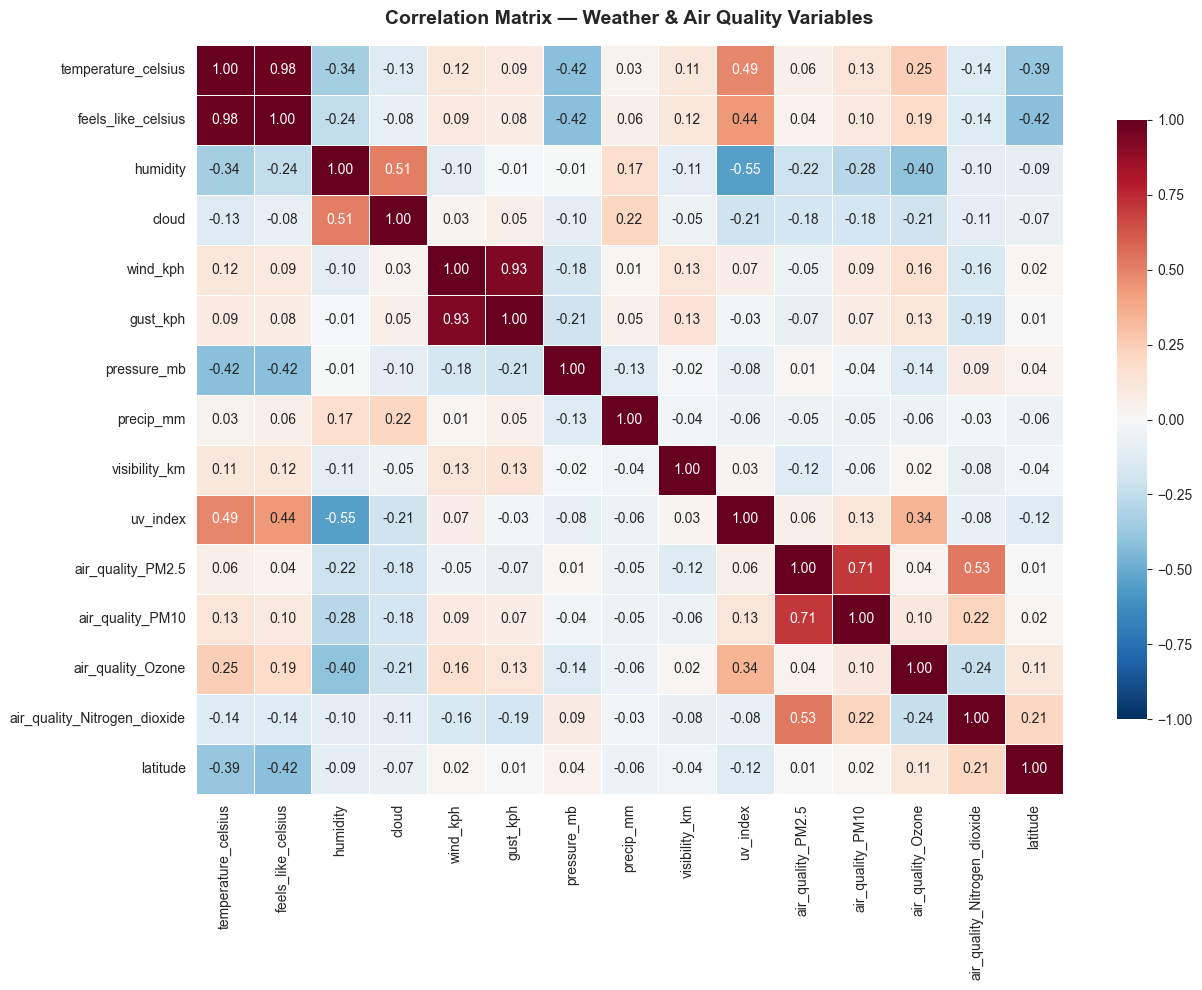


Strongest correlations (sorted by absolute strength):
----------------------------------------------------------------------
  + 0.984  |  temperature_celsius            ↔ feels_like_celsius
  + 0.931  |  wind_kph                       ↔ gust_kph
  + 0.707  |  air_quality_PM2.5              ↔ air_quality_PM10
  - 0.549  |  humidity                       ↔ uv_index
  + 0.529  |  air_quality_PM2.5              ↔ air_quality_Nitrogen_dioxide
  + 0.510  |  humidity                       ↔ cloud
  + 0.490  |  temperature_celsius            ↔ uv_index
  + 0.436  |  feels_like_celsius             ↔ uv_index
  - 0.419  |  temperature_celsius            ↔ pressure_mb
  - 0.419  |  feels_like_celsius             ↔ pressure_mb
  - 0.417  |  feels_like_celsius             ↔ latitude
  - 0.402  |  humidity                       ↔ air_quality_Ozone
  - 0.388  |  temperature_celsius            ↔ latitude
  + 0.341  |  uv_index                       ↔ air_quality_Ozone
  - 0.339  |  temperature_celsi

In [3]:
numeric_features = [
    'temperature_celsius', 'feels_like_celsius', 'humidity', 'cloud',
    'wind_kph', 'gust_kph', 'pressure_mb', 'precip_mm', 'visibility_km',
    'uv_index', 'air_quality_PM2.5', 'air_quality_PM10',
    'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
    'latitude'
]

corr = df[numeric_features].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Weather & Air Quality Variables',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
save_fig('phase2_correlation_heatmap')
plt.show()

# Print strongest correlations WITH SIGNS preserved
print("\nStrongest correlations (sorted by absolute strength):")
print("-" * 70)

# Get all correlation pairs
pairs = corr.unstack().reset_index()
pairs.columns = ['var1', 'var2', 'corr']

# Remove self-correlations and duplicate (A,B) vs (B,A)
pairs = pairs[pairs['var1'] != pairs['var2']]
pairs['sorted_pair'] = pairs.apply(lambda r: tuple(sorted([r['var1'], r['var2']])), axis=1)
pairs = pairs.drop_duplicates(subset='sorted_pair').drop(columns='sorted_pair')

# Sort by absolute strength but keep the actual sign
pairs['abs_corr'] = pairs['corr'].abs()
pairs = pairs.sort_values('abs_corr', ascending=False).head(15)

for _, row in pairs.iterrows():
    sign = '+' if row['corr'] >= 0 else '-'
    print(f"  {sign} {abs(row['corr']):.3f}  |  {row['var1']:30s} ↔ {row['var2']}")

###  Key Insights from the Correlation Analysis

**Strong positive relationships (variables move together):**
- **`temperature` ↔ `feels_like` (+0.98)**: Near-perfect — `feels_like` is *derived from* temperature. Using both would be redundant; we'll keep only `temperature_celsius`.
- **`wind_kph` ↔ `gust_kph` (+0.93)**: Gusts are peaks of sustained wind — same physical signal. Drop one in modeling.
- **`PM2.5` ↔ `PM10` (+0.71)**: Pollution metrics co-occur — both come from similar sources (vehicles, fires, dust).
- **`PM2.5` ↔ `NO₂` (+0.53)**: Vehicle emissions drive both fine particulates and nitrogen dioxide. *Useful insight for AQI analysis in Phase 6.*
- **`humidity` ↔ `cloud` (+0.51)**: Clouds form when air is saturated with water vapor. Direct physical mechanism.
- **`uv_index` ↔ `temperature` (+0.49)**: Hot days have high UV — both peak in summer / at low latitudes.

**Strong negative relationships (variables move oppositely):**
- **`humidity` ↔ `uv_index` (-0.55)**: Humid air = cloudier skies = less UV reaching the ground. Confirmed physical mechanism.
- **`temperature` ↔ `pressure` (-0.42)**: Low-pressure systems bring cold/stormy weather; high pressure brings clear, warm days.
- **`temperature` ↔ `latitude` (-0.39)**: Tropics are hot, poles are cold — the most fundamental climate fact, validated.
- **`humidity` ↔ `Ozone` (-0.40)**: High humidity reduces ground-level ozone formation (water vapor scavenges ozone).
- **`humidity` ↔ `temperature` (-0.34)**: Hotter air *can hold* more moisture, but warmer regions in our data tend to be drier (deserts skew this).

**Weak / no relationships (independent signals):**
- **`precip_mm` ↔ almost everything**: Rainfall is bursty and hard to predict from instantaneous measurements. Only weakly correlated with humidity (+0.17) and cloud (+0.22). *This is why precipitation is the hardest variable to forecast.*
- **`visibility_km` ↔ most variables**: Visibility is mostly capped at 10 km, so the variation isn't strong enough to correlate with anything.
- **`latitude` ↔ pollution metrics**: Air quality is driven by local activity (cities, traffic, industry), not latitude.

**Key takeaways for modeling :**
1. **Drop redundant features**: `feels_like_celsius` (use `temperature_celsius`), `gust_kph` (use `wind_kph`).
2. **Use these features for temperature forecasting**: humidity, pressure, cloud, uv_index, latitude, month/day_of_year (cyclical).

## 2. Temperature by Latitude Zone

Latitude is the single strongest predictor of temperature. Let's verify this 
visually — we expect tropical zones to be warmest, polar zones coldest.

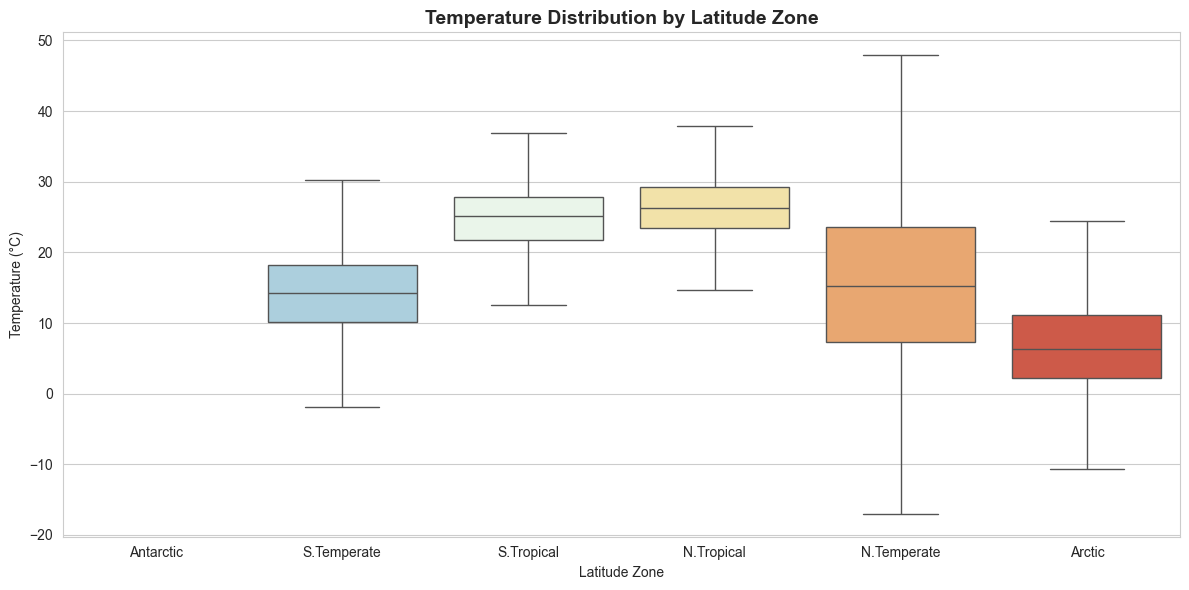

In [5]:
df['lat_zone'] = pd.cut(df['latitude'],
    bins=[-90, -60, -30, 0, 30, 60, 90],
    labels=['Antarctic', 'S.Temperate', 'S.Tropical',
            'N.Tropical', 'N.Temperate', 'Arctic'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='lat_zone', y='temperature_celsius',
            palette='RdYlBu_r', showfliers=False)
plt.title('Temperature Distribution by Latitude Zone',
          fontsize=14, fontweight='bold')
plt.xlabel('Latitude Zone')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
save_fig('phase2_temperature_by_latitude_zone')
plt.show()

### Insights from Box plot

**Key patterns:**
- **Tropical zones (both N & S)** have the highest temperatures (medians ~25–26°C) 
  AND the smallest seasonal variation — narrow boxes show year-round consistency.
- **Temperate zones** show the largest variability — N.Temperate spans -17°C to +47°C, 
  reflecting cities with brutal winters and hot summers (London, NYC, Beijing).
- **Polar zones** (Antarctic, Arctic) have low representation in our dataset because 
  few capital cities exist at extreme latitudes.

**Modeling implication**: Forecasting accuracy will likely vary by climate zone. 
Tropical cities (low variance) will be easiest; temperate cities (large swings) 
will be hardest.

**Bias note**: Our dataset over-represents Northern Temperate climates, which 
limits the global generalizability of any single model.

## 3. Hemisphere Seasonality

A classic climate fact: when the Northern hemisphere is in summer, the Southern 
is in winter — and vice versa. Plotting average monthly temperature for each 
hemisphere should produce **mirror-image curves**.

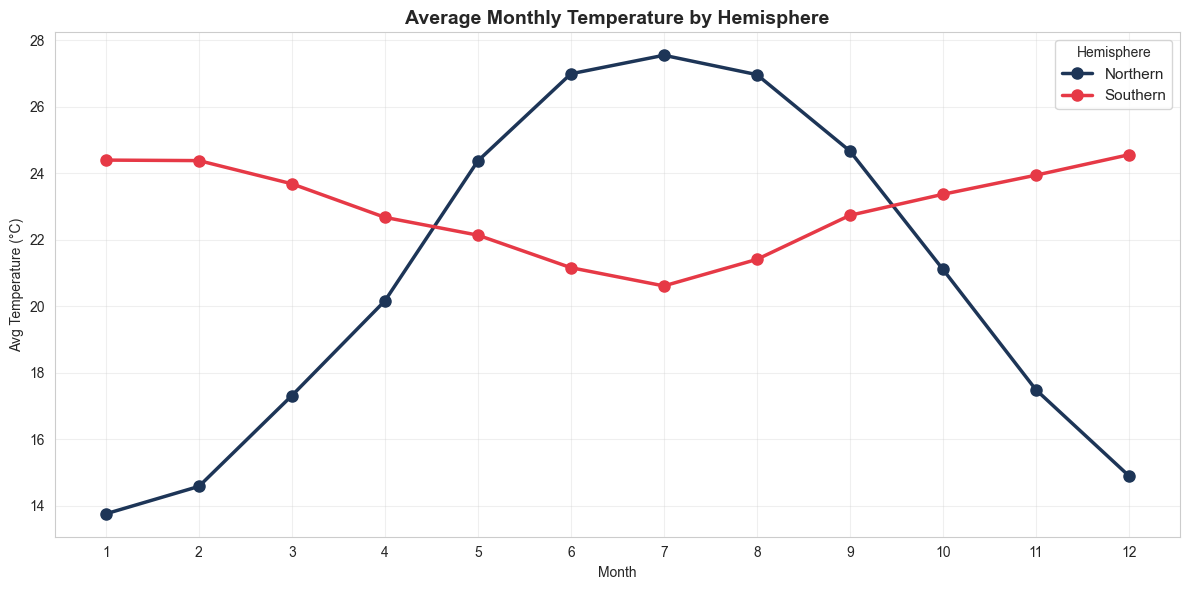

In [6]:
df['hemisphere'] = np.where(df['latitude'] >= 0, 'Northern', 'Southern')
monthly = df.groupby(['month', 'hemisphere'])['temperature_celsius'].mean().reset_index()

plt.figure(figsize=(12, 6))
for hemi, color in [('Northern', '#1D3557'), ('Southern', '#E63946')]:
    data = monthly[monthly['hemisphere'] == hemi]
    plt.plot(data['month'], data['temperature_celsius'],
             marker='o', linewidth=2.5, label=hemi, color=color, markersize=8)

plt.title('Average Monthly Temperature by Hemisphere',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Temperature (°C)')
plt.xticks(range(1, 13))
plt.legend(title='Hemisphere', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
save_fig('phase2_monthly_temp_by_hemisphere')
plt.show()

### 🧠 Reading this chart
The curves are inverted — Northern peaks in July (summer), Southern peaks in 
January. This validates that any model we build needs to know hemisphere/latitude 
to forecast correctly. A model trained only on Northern cities would predict 
backwards for Sydney.

## 4. Hottest & Coldest Capital Cities

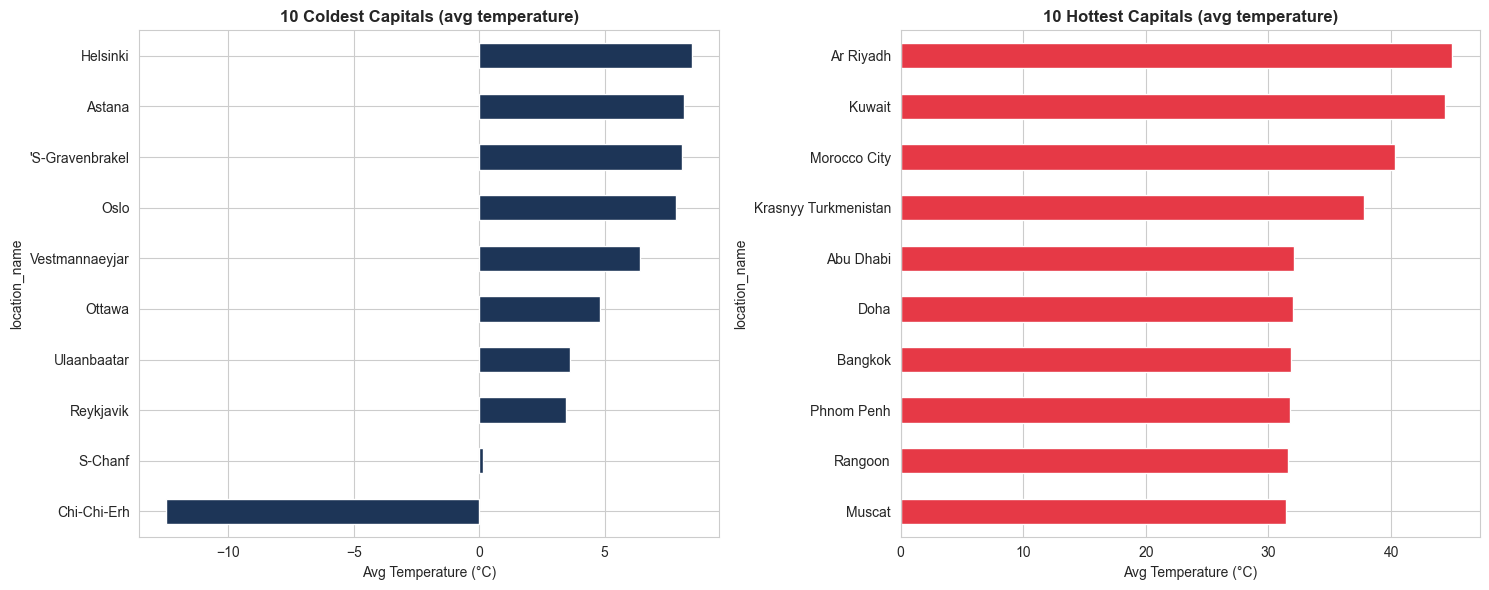

In [7]:
city_avg_temp = df.groupby('location_name')['temperature_celsius'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

city_avg_temp.head(10).plot(kind='barh', ax=axes[0],
                             color='#1D3557', edgecolor='white')
axes[0].set_title('10 Coldest Capitals (avg temperature)', fontweight='bold')
axes[0].set_xlabel('Avg Temperature (°C)')

city_avg_temp.tail(10).plot(kind='barh', ax=axes[1],
                             color='#E63946', edgecolor='white')
axes[1].set_title('10 Hottest Capitals (avg temperature)', fontweight='bold')
axes[1].set_xlabel('Avg Temperature (°C)')

plt.tight_layout()
save_fig('phase2_hottest_coldest_cities')
plt.show()

## 5. Air Quality by Continent

A key question for our advanced analyses: **does air quality vary geographically?** 
This view groups all cities by continent and compares their PM2.5 distributions.

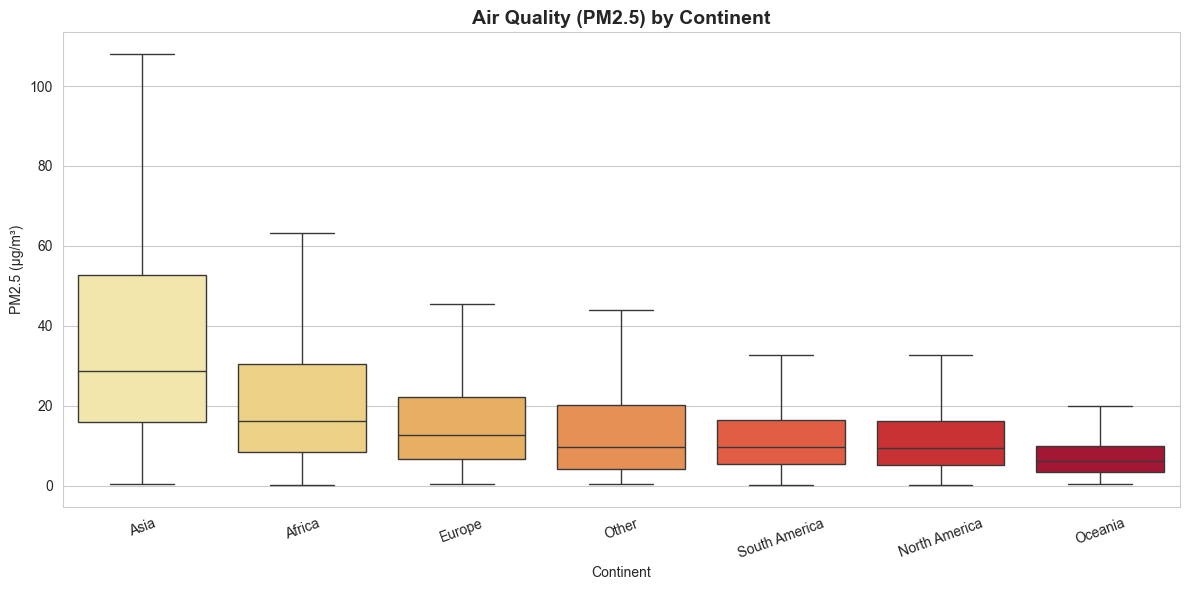


Median PM2.5 by continent:
continent
Asia             28.65
Africa           16.25
Europe           12.65
Other             9.80
South America     9.62
North America     9.41
Oceania           6.25
Name: air_quality_PM2.5, dtype: float64


In [8]:
plt.figure(figsize=(12, 6))
order = df.groupby('continent')['air_quality_PM2.5'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='continent', y='air_quality_PM2.5',
            order=order, showfliers=False, palette='YlOrRd')
plt.title('Air Quality (PM2.5) by Continent', fontsize=14, fontweight='bold')
plt.xlabel('Continent')
plt.ylabel('PM2.5 (µg/m³)')
plt.xticks(rotation=20)
plt.tight_layout()
save_fig('phase2_aqi_by_continent')
plt.show()

print("\nMedian PM2.5 by continent:")
print(df.groupby('continent')['air_quality_PM2.5'].median()
        .sort_values(ascending=False).round(2))

###  Insights
- Asia leads global PM2.5 by a wide margin (median 28.65 vs. Oceania's 6.25).
- Asia's tall box reveals huge city-to-city variation — likely tied to local industry/traffic density.
- Sets up Phase 6 analysis: which weather conditions (wind, pressure, humidity) correlate with bad AQI days?

## 6. Forecasting Targets — Data Verification

Our 3 forecasting cities 'London', 'New Delhi', 'Canberra' need enough data to train 
time series models. We need to verify each city has at least ~700 daily readings 
(roughly 1 year of coverage).

In [6]:
target_cities = ['London', 'New Delhi', 'Canberra']
city_check = df[df['location_name'].isin(target_cities)].groupby('location_name').agg(
    rows=('last_updated', 'count'),
    start=('last_updated', 'min'),
    end=('last_updated', 'max'),
    avg_temp=('temperature_celsius', 'mean'),
    avg_humidity=('humidity', 'mean'),
).round(2)

print("Data availability for forecasting cities:")
city_check



Data availability for forecasting cities:


,rows,start,end,avg_temp,avg_humidity
location_name,,,,,
Canberra,712,2024-05-16 18:45:00,2026-05-01 16:30:00,15.45,63.83
London,711,2024-05-16 09:45:00,2026-05-01 07:45:00,12.10,78.43
New Delhi,712,2024-05-16 14:15:00,2026-05-01 12:00:00,29.85,45.01


In [7]:
print("\nDaily reading frequency:")
for city in target_cities:
    sub = df[df['location_name'] == city]
    days = (sub['last_updated'].max() - sub['last_updated'].min()).days
    print(f"  {city}: {len(sub)} readings over {days} days = "
          f"{len(sub)/days:.2f} readings/day")


Daily reading frequency:
  London: 711 readings over 714 days = 1.00 readings/day
  New Delhi: 712 readings over 714 days = 1.00 readings/day
  Canberra: 712 readings over 714 days = 1.00 readings/day


###  Insights
- All 3 cities have ~712 readings over 714 days = perfectly regular daily data.
- Climate diversity confirmed: New Delhi (hot/dry), London (cool/damp), Canberra (mild/temperate).
- No data gaps → models will train cleanly without imputation.

## 7. Time Series of Target Cities

The actual signal we'll forecast — daily average temperature for each target city. 
Look for: seasonal cycles, trend, smoothness.

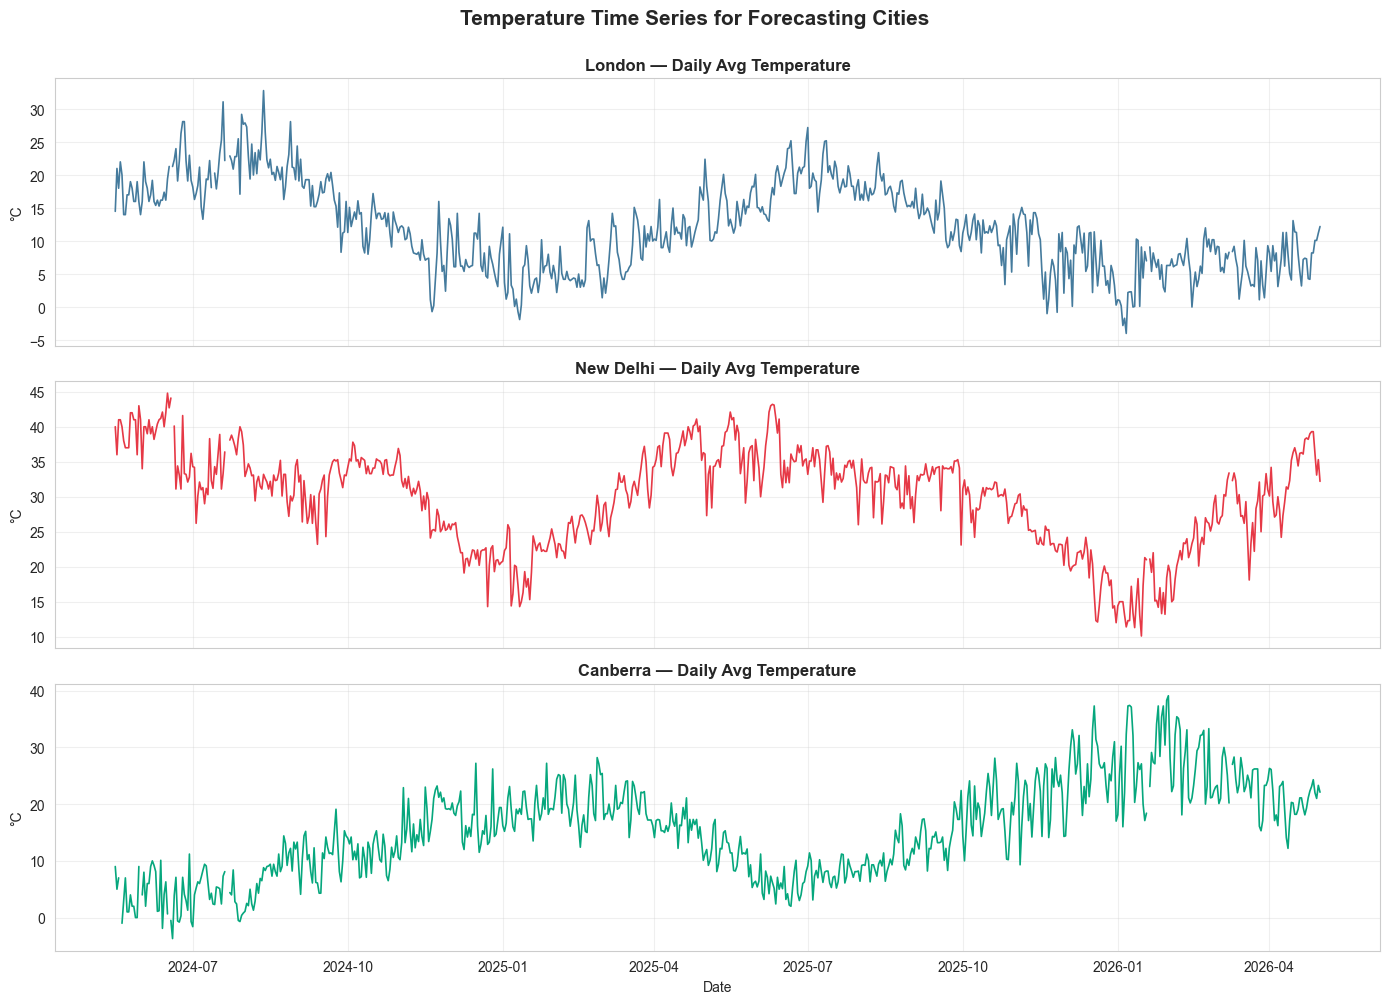

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = {'London': '#457B9D', 'New Delhi': '#E63946', 'Canberra': '#06A77D'}

for ax, city in zip(axes, target_cities):
    sub = df[df['location_name'] == city].sort_values('last_updated')
    daily = sub.set_index('last_updated')['temperature_celsius'].resample('D').mean()
    ax.plot(daily.index, daily.values, color=colors[city], linewidth=1.2)
    ax.set_title(f'{city} — Daily Avg Temperature', fontweight='bold')
    ax.set_ylabel('°C')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('Temperature Time Series for Forecasting Cities',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
save_fig('phase2_target_cities_timeseries')
plt.show()

###  Insights
- **Two full seasonal cycles** are visible — perfect for time series modeling.
- **London** shows a clean sinusoidal pattern (cold winter, warm summer).
- **New Delhi** has the largest amplitude (~30°C swing) with a sharp pre-monsoon peak.
- **Canberra peaks in December–January** — visual confirmation of Southern hemisphere inversion.
- Each city's distinct signature will let us evaluate which models work best for which climate.

## 8. Weather Conditions Distribution

The `condition_text` column gives a categorical summary of weather state. 
Useful for understanding the variety in the data.

In [10]:
# Normalize condition_text — fix capitalization inconsistencies
df['condition_text'] = df['condition_text'].str.strip().str.title()

# Verify the fix
print("After normalization:")
print(df['condition_text'].value_counts().head(15))

After normalization:
condition_text
Partly Cloudy                          48697
Sunny                                  39911
Patchy Rain Nearby                     11571
Overcast                                7536
Clear                                   7366
Mist                                    5819
Light Rain                              4332
Light Rain Shower                       3171
Fog                                     1732
Cloudy                                  1663
Moderate Or Heavy Rain With Thunder     1108
Moderate Rain                           1051
Patchy Light Rain With Thunder           859
Light Drizzle                            689
Light Snow                               524
Name: count, dtype: int64


In [12]:
df.to_parquet("../data/weather_cleaned.parquet", index=False)
print("✅ Updated cleaned dataset with normalized condition text")

✅ Updated cleaned dataset with normalized condition text


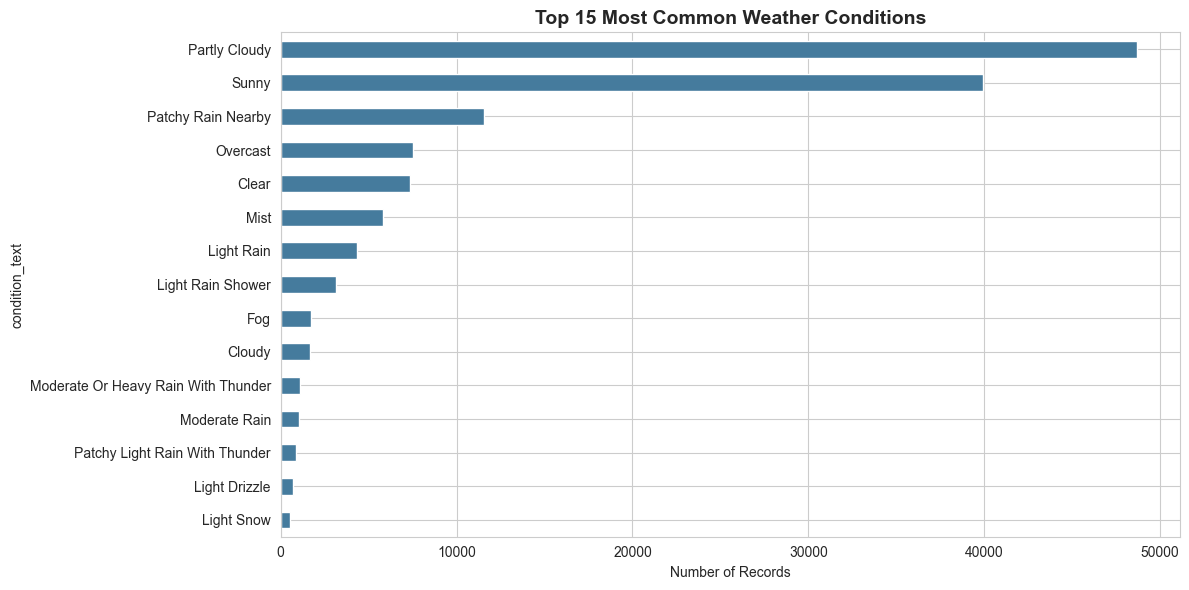

In [11]:
top_conditions = df['condition_text'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_conditions.plot(kind='barh', color='#457B9D', edgecolor='white')
plt.title('Top 15 Most Common Weather Conditions',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Records')
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig('phase2_top_conditions')
plt.show()

###  Insights
- "Sunny" and "Partly Cloudy" dominate (~58% of all records combined).
- Severe weather (storms, heavy rain) is rare (<1%) — confirms the dataset captures mostly routine weather.
- **Data quality fix applied**: Normalized capitalization in `condition_text` to merge duplicates like "partly cloudy" and "Partly Cloudy" into a single category.
- Class imbalance motivates anomaly detection (Phase 3) for catching rare extreme conditions.

## 9. Key Findings Summary

In [12]:
findings = {
    'total_cities': df['location_name'].nunique(),
    'total_countries': df['country'].nunique(),
    'date_range_days': (df['last_updated'].max() - df['last_updated'].min()).days,
    'global_avg_temp_C': round(df['temperature_celsius'].mean(), 2),
    'global_avg_humidity_pct': round(df['humidity'].mean(), 2),
    'hottest_city': city_avg_temp.idxmax(),
    'coldest_city': city_avg_temp.idxmin(),
    'most_polluted_continent': df.groupby('continent')['air_quality_PM2.5'].median().idxmax(),
    'cleanest_continent': df.groupby('continent')['air_quality_PM2.5'].median().idxmin(),
    'top_correlation_with_temp': corr['temperature_celsius'].drop('temperature_celsius').abs().idxmax(),
}

print("📋 KEY FINDINGS:")
print("-" * 60)
for k, v in findings.items():
    print(f"  • {k:35s} {v}")

📋 KEY FINDINGS:
------------------------------------------------------------
  • total_cities                        257
  • total_countries                     211
  • date_range_days                     715
  • global_avg_temp_C                   21.25
  • global_avg_humidity_pct             66.7
  • hottest_city                        Ar Riyadh
  • coldest_city                        Chi-Chi-Erh
  • most_polluted_continent             Asia
  • cleanest_continent                  Oceania
  • top_correlation_with_temp           feels_like_celsius


## ✅ Phase 2 Complete

**Key takeaways for modeling:**
1. **Latitude** is the strongest geographic predictor of temperature — must be a feature
2. **Feels_like / wind / gust** are highly redundant with their counterparts — pick one of each
3. **Hemisphere matters** — seasons are inverted for Sydney (Southern)
4. **Air quality varies hugely** by continent — Asia/Africa lead in PM2.5
5. **All 3 target cities have sufficient data** for forecasting

**Saved figures:**
- `phase2_correlation_heatmap.png`
- `phase2_temperature_by_latitude_zone.png`
- `phase2_monthly_temp_by_hemisphere.png`
- `phase2_hottest_coldest_cities.png`
- `phase2_aqi_by_continent.png`
- `phase2_target_cities_timeseries.png`
- `phase2_top_conditions.png`

**Next:** Phase 3 — Anomaly Detection